# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


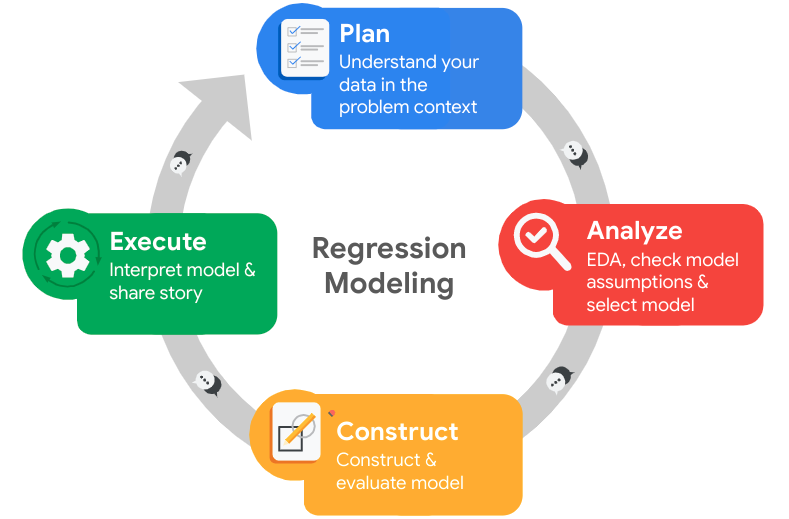

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




Stakeholders:
The main stakeholders are the HR team and Salifort Motors' leadership, who want to understand employee turnover and improve employee retention.

Mission:
Identify factors associated with employee turnover and develop a model that predicts whether an employee is likely to leave, allowing HR to design more targeted retention initiatives.

Ethical considerations:
Consider employee data privacy, algorithmic bias, and fair treatment. The model should support HR decision-making rather than be used to unfairly penalize individual employees.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [23]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns = {
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident',
    'Department': 'department'
    
})

# Display all column names after the update
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [24]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [26]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [28]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated(keep = False)].sort_values(
by=list(df0.columns)).head(10)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
30,0.09,0.62,6,294,4,0,1,0,accounting,low
12030,0.09,0.62,6,294,4,0,1,0,accounting,low
14241,0.09,0.62,6,294,4,0,1,0,accounting,low
71,0.09,0.77,5,275,4,0,1,0,product_mng,medium
12071,0.09,0.77,5,275,4,0,1,0,product_mng,medium
14282,0.09,0.77,5,275,4,0,1,0,product_mng,medium
652,0.09,0.77,6,290,4,0,1,0,technical,medium
12652,0.09,0.77,6,290,4,0,1,0,technical,medium
14863,0.09,0.77,6,290,4,0,1,0,technical,medium
278,0.09,0.78,6,254,4,0,1,0,support,low


In [30]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates().copy()

df1.shape

(11991, 10)

In [31]:
# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [32]:
df1.duplicated().sum()

0

### Check outliers

Check for outliers in the data.

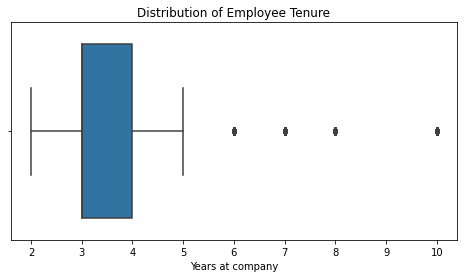

In [33]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize = (8,4))
sns.boxplot(x=df1['time_spend_company'])
plt.title('Distribution of Employee Tenure')
plt.xlabel('Years at company')
plt.show()


In [34]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)

IQR = Q3 - Q1
print(IQR)

1.0


In [35]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

print(f"({lower_limit}, {upper_limit})")

(1.5, 5.5)


In [37]:
outliners = df1[
    (df1['time_spend_company'] < lower_limit) |
    (df1['time_spend_company'] > upper_limit)
]

print("Number of outliners: ", len(outliners))

Number of outliners:  824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




During the analyze stage, I examined the distributions and relationships between variables to identify potential factors associated with employee turnover. The data contained no missing values, duplicate records were removed, and column names were standardized. I also identified 824 outliers in time_spend_company using the IQR method. However, these observations were not removed at this stage because longer employee tenure is plausible, and the treatment of outliers should depend on the predictive model selected. EDA is useful before modelling because it helps identify patterns, unusual observations, relationships between variables, and potential data-quality issues.

Ethical considerations include employee privacy, potential bias, and fair interpretation of the results. Any patterns identified should not be assumed to be causal, and predictions should support HR’s retention strategy rather than be used to unfairly treat individual employees. Resources used include the course materials and Python documentation for pandas, Matplotlib, and Seaborn.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [39]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
df1['left'].value_counts()

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
df1['left'].value_counts(normalize=True)*100

0    83.39588
1    16.60412
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

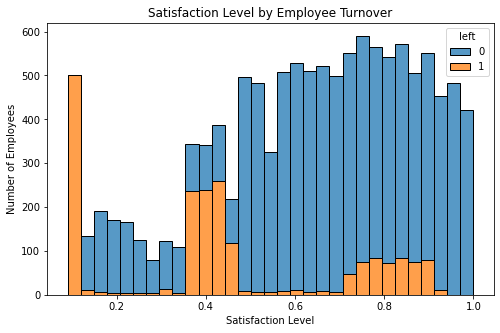

In [40]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df1,
    x='satisfaction_level',
    hue='left',
    multiple='stack'
)

plt.title('Satisfaction Level by Employee Turnover')
plt.xlabel('Satisfaction Level')
plt.ylabel('Number of Employees')
plt.show()


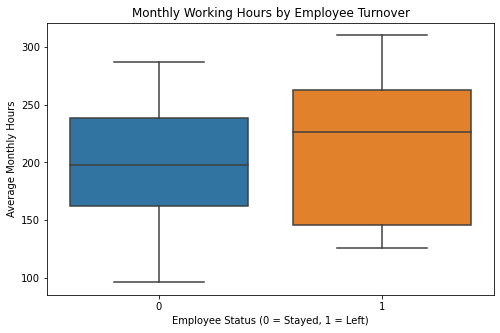

In [41]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df1,
    x='left',
    y='average_monthly_hours'
)

plt.title('Monthly Working Hours by Employee Turnover')
plt.xlabel('Employee Status (0 = Stayed, 1 = Left)')
plt.ylabel('Average Monthly Hours')
plt.show()


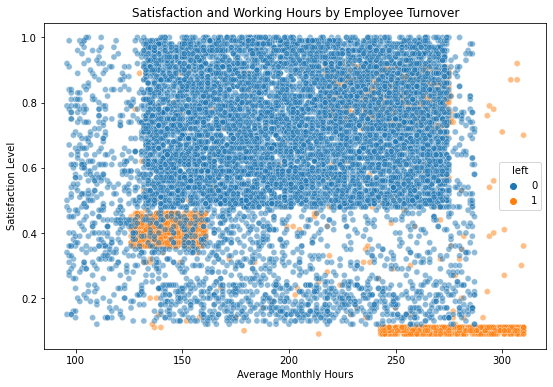

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df1,
    x='average_monthly_hours',
    y='satisfaction_level',
    hue='left',
    alpha=0.5
)

plt.title('Satisfaction and Working Hours by Employee Turnover')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Satisfaction Level')
plt.show()


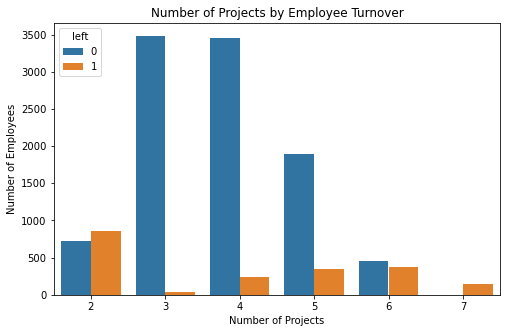

In [45]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df1,
    x='number_project',
    hue='left'
)

plt.title('Number of Projects by Employee Turnover')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.show()


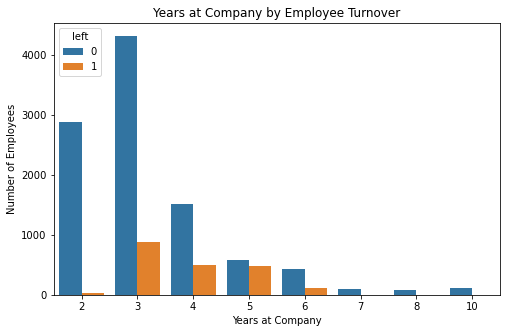

In [46]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df1,
    x='time_spend_company',
    hue='left'
)

plt.title('Years at Company by Employee Turnover')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.show()


In [47]:
# Create a plot as needed
### YOUR CODE HERE ###
promotion_turnover = pd.crosstab(
    df1['promotion_last_5years'],
    df1['left'],
    normalize='index'
) * 100

promotion_turnover


left,0,1
promotion_last_5years,,
0,83.177808,16.822192
1,96.059113,3.940887


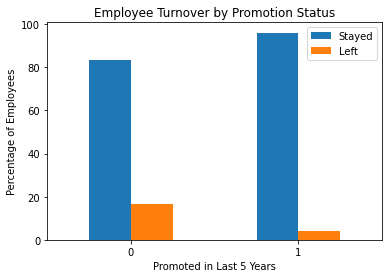

In [48]:
# Create a plot as needed
### YOUR CODE HERE ###
promotion_turnover.plot(kind='bar')

plt.title('Employee Turnover by Promotion Status')
plt.xlabel('Promoted in Last 5 Years')
plt.ylabel('Percentage of Employees')
plt.legend(['Stayed', 'Left'])
plt.xticks(rotation=0)
plt.show()



In [49]:
# Create a plot as needed
### YOUR CODE HERE ###
salary_turnover = pd.crosstab(
    df1['salary'],
    df1['left'],
    normalize='index'
) * 100

salary_turnover


left,0,1
salary,,
high,95.151515,4.848485
low,79.547038,20.452962
medium,85.383007,14.616993


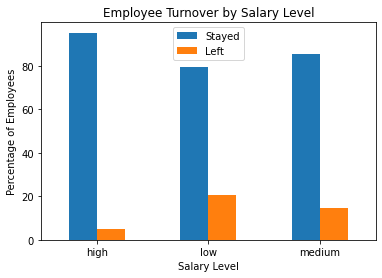

In [50]:
salary_turnover.plot(kind='bar')

plt.title('Employee Turnover by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Percentage of Employees')
plt.legend(['Stayed', 'Left'])
plt.xticks(rotation=0)
plt.show()


### Insights

EDA suggests that employee turnover is associated with several factors, including satisfaction, workload, number of projects, tenure, promotion history, and salary. The relationships are not always linear: employees who left appear in distinct satisfaction and workload groups, while turnover is particularly noticeable among employees with very low or high project loads and around 3–5 years of tenure. Employees with low salaries also had higher turnover (20.5%) than medium- (14.6%) and high-salary employees (4.8%), while employees promoted within the last five years had substantially lower turnover.

These findings suggest that employee turnover may involve different employee segments rather than a single cause. The results show associations rather than causal relationships, so HR should use them to identify areas for further investigation rather than assume that changing one factor will necessarily prevent turnover.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

### Modeling

Add as many cells as you need to conduct the modeling process.

In [51]:
### YOUR CODE HERE ###
# Logistic Regression

X = df1.drop('left', axis = 1)
y = df1['left']

In [52]:
print(X.shape)
print(y.shape)
X.head()

(11991, 9)
(11991,)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,0,sales,low
1,0.80,0.86,5,262,6,0,0,sales,medium
2,0.11,0.88,7,272,4,0,0,sales,medium
3,0.72,0.87,5,223,5,0,0,sales,low
4,0.37,0.52,2,159,3,0,0,sales,low


In [53]:
X = pd.get_dummies(
    X,
    columns = ['department', 'salary'],
    drop_first = True
)

In [56]:
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,1,0,0,1,0


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.25,
    stratify = y,
    random_state = 42
)

In [60]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

print('\nTraining target:')
print(y_train.value_counts(normalize=True))

print('\nTest target:')
print(y_test.value_counts(normalize=True))


X_train: (8993, 18)
X_test: (2998, 18)

Training target:
0    0.833982
1    0.166018
Name: left, dtype: float64

Test target:
0    0.833889
1    0.166111
Name: left, dtype: float64


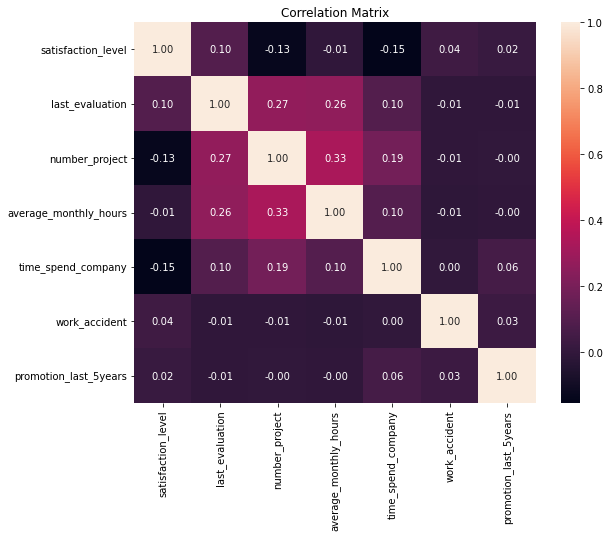

In [61]:
# Assumption check

numeric_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'time_spend_company',
    'work_accident',
    'promotion_last_5years'
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    df1[numeric_cols].corr(),
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [63]:
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(
    max_iter = 1000,
    random_state = 42
)

log_clf.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [65]:
y_pred = log_clf.predict(X_test)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))



Accuracy: 0.8342228152101401
Precision: 0.5024630541871922
Recall: 0.20481927710843373
F1: 0.29101283880171186

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.50      0.20      0.29       498

    accuracy                           0.83      2998
   macro avg       0.68      0.58      0.60      2998
weighted avg       0.80      0.83      0.80      2998



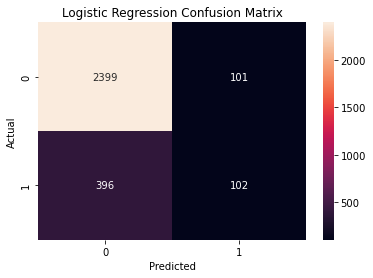

In [67]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


**logistic regression**

The logistic regression model achieved 83.4% accuracy, but its performance in identifying employees who left was relatively weak. For the turnover class, precision was 50.2%, recall was only 20.5%, and the F1-score was 0.29. The model correctly identified only 102 of 498 employees who left, while missing 396.

Therefore, although overall accuracy appears reasonable, it is largely influenced by the class imbalance and the model’s strong performance in predicting employees who stayed. The low recall for turnover means the model would miss many at-risk employees, limiting its usefulness for targeted HR retention initiatives. A tree-based model should be explored next to better capture the non-linear relationships identified during EDA.

In [69]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

NameError: name 'param_grid' is not defined

In [70]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 0.5]
}

In [72]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,      # Use all available CPU cores
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  5.0min finished


GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=1,
                                              oob_score=False, random_state=42,
                                     

In [73]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validation F1 score:
0.9508863482775327


In [74]:
rf_best = grid_search.best_estimator_

In [75]:
y_pred_rf = rf_best.predict(X_test)

In [76]:
print("\nRandom Forest Test Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))



Random Forest Test Performance
Accuracy: 0.9859906604402935
Precision: 0.9913793103448276
Recall: 0.9236947791164659
F1: 0.9563409563409564

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



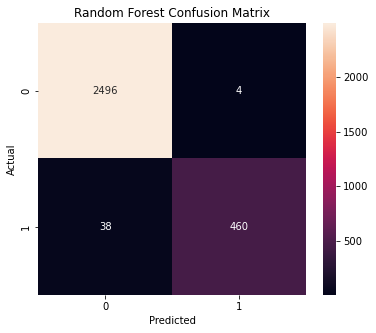

In [77]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

Random Forest substantially outperformed logistic regression, achieving 98.6% accuracy and an F1-score of 95.6% for employees who left. The model correctly identified 460 of 498 employees who left, corresponding to 92.4% recall, while producing only four false positives. This suggests that employee turnover is driven by nonlinear relationships and interactions that Random Forest captures much more effectively than logistic regression.

In [78]:
# XGBoost Model

import xgboost as xgb

In [79]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=1
)


In [80]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.1, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=6, max_leaves=0,
              min_child_weight=2, missing=nan, monotone_constraints='()',
              n_estimators=500, n_jobs=1, num_parallel_tree=1,
              objective='binary:logistic', predictor='auto', random_state=42,
              reg_alpha=0, ...)

In [81]:
y_pred_xgb = xgb_model.predict(X_test)

In [82]:
print("XGBoost Test Performance")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Test Performance
Accuracy: 0.9829886591060707
Precision: 0.9705263157894737
Recall: 0.9257028112449799
F1: 0.947584789311408

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2500
           1       0.97      0.93      0.95       498

    accuracy                           0.98      2998
   macro avg       0.98      0.96      0.97      2998
weighted avg       0.98      0.98      0.98      2998



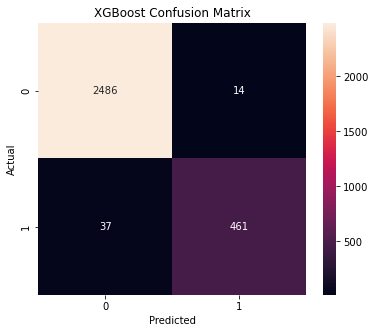

In [83]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()


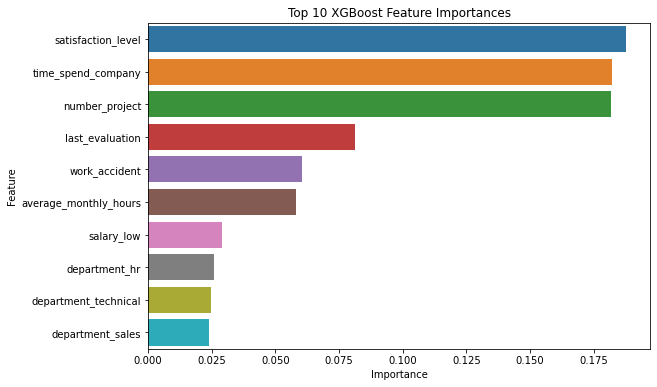

In [84]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    'Importance',
    ascending=False
)

xgb_importance.head(10)



plt.figure(figsize=(9, 6))

sns.barplot(
    data=xgb_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [85]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

comparison



,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.834223,0.502463,0.204819,0.291013
1,Random Forest,0.985991,0.991379,0.923695,0.956341
2,XGBoost,0.982989,0.970526,0.925703,0.947585


**Summary**

Both tree-based models substantially outperformed logistic regression. Random Forest achieved the strongest overall performance, with 98.6% accuracy, 99.1% precision, 92.4% recall, and a 95.6% F1-score. XGBoost achieved a slightly higher recall of 92.6%, identifying 461 of 498 employees who left, but produced more false positives. Overall, the results indicate that nonlinear relationships and interactions between employee characteristics are important for predicting turnover.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The models show that employee turnover can be predicted effectively from the available workforce data. Random Forest produced the strongest overall performance, achieving 98.6% accuracy, 99.1% precision, 92.4% recall, and an F1-score of 95.6%, with cross-validation results suggesting good generalisation. The analysis also indicates that satisfaction level, time spent at the company, number of projects, working hours, and employee evaluation are important factors associated with turnover. Management could therefore use these indicators to identify groups at higher risk and investigate workload, employee satisfaction, career progression, and retention initiatives.

The model could be improved with additional relevant variables and future employee data, as well as continued monitoring for changes in performance. Importantly, predictions should be used as a decision-support tool rather than to make employment decisions automatically. Employee data should be handled confidentially, model performance should be monitored across different employee groups, and managers should investigate the underlying circumstances before taking action.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




In [86]:
print("Best Random Forest Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)


Best Random Forest Parameters:
{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV F1 Score:
0.9508863482775327


In [87]:
# Predictions
y_pred_rf_train = rf_best.predict(X_train)
y_pred_rf_test = rf_best.predict(X_test)

print("Random Forest - Training Performance")
print("Accuracy:", accuracy_score(y_train, y_pred_rf_train))
print("Precision:", precision_score(y_train, y_pred_rf_train))
print("Recall:", recall_score(y_train, y_pred_rf_train))
print("F1:", f1_score(y_train, y_pred_rf_train))

print("\nRandom Forest - Test Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_test))
print("Precision:", precision_score(y_test, y_pred_rf_test))
print("Recall:", recall_score(y_test, y_pred_rf_test))
print("F1:", f1_score(y_test, y_pred_rf_test))


Random Forest - Training Performance
Accuracy: 0.9886578449905482
Precision: 0.9929128277817151
Recall: 0.9383791024782318
F1: 0.9648760330578513

Random Forest - Test Performance
Accuracy: 0.9859906604402935
Precision: 0.9913793103448276
Recall: 0.9236947791164659
F1: 0.9563409563409564


In [88]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_results = cross_validate(
    rf_best,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(
        f"{metric.capitalize()}: "
        f"{scores.mean():.4f} (+/- {scores.std():.4f})"
    )


5-Fold Cross-Validation Results
Accuracy: 0.9837 (+/- 0.0039)
Precision: 0.9863 (+/- 0.0061)
Recall: 0.9143 (+/- 0.0226)
F1: 0.9488 (+/- 0.0126)


In [89]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)
pr_auc = average_precision_score(y_test, y_prob_rf)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)


ROC-AUC: 0.980281124497992
PR-AUC: 0.9626793644699678


### Summary of model results

Three classification models were evaluated to predict employee turnover: logistic regression, random forest, and XGBoost. Logistic regression achieved an F1-score of 0.291, while the tree-based models performed substantially better. Random forest achieved the strongest overall test performance, with 98.6% accuracy, 99.1% precision, 92.4% recall, and an F1-score of 0.956. XGBoost performed similarly, with 98.3% accuracy and an F1-score of 0.948.

The random forest model was selected as the final model. Its training F1-score (0.965), test F1-score (0.956), and 5-fold cross-validation F1-score (0.949 ± 0.013) were consistent, indicating good generalisation with no substantial evidence of overfitting. The model also achieved a ROC-AUC of 0.980 and PR-AUC of 0.963. Overall, the results suggest that the model can effectively identify employees at risk of leaving while producing relatively few false-positive predictions.

### Conclusion, Recommendations, Next Steps

The analysis shows that employee turnover can be predicted effectively using the available workforce data. Among the three models tested, Random Forest produced the strongest overall results, achieving 98.6% accuracy, 99.1% precision, 92.4% recall, and a 95.6% F1-score. The model also performed consistently across training, testing, and cross-validation, suggesting good generalisation. Important predictors included employee satisfaction, time spent at the company, number of projects, working hours, and evaluation scores.

Salifort Motors should use these findings to support a more proactive retention strategy. Rather than waiting for employees to resign, HR could monitor patterns associated with higher turnover risk and investigate issues such as low satisfaction, excessive workloads, project allocation, and career progression. These factors should be treated as indicators for further investigation rather than assuming that they directly cause employees to leave.

As a next step, the company could pilot the model as an HR decision-support tool, monitor its performance on new employee data, and evaluate whether retention interventions actually reduce turnover. Additional employee-related variables could also be incorporated to improve the analysis. Because this involves sensitive employee data, predictions should be reviewed by people, protected appropriately, and not used as the sole basis for employment decisions.